In [ ]:
pip install transformers torch datasets sklearn

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

Device: cuda
GPU: Tesla T4
train_balanced.csv: 55394->55394 rows after NA drop
test.csv: 12544->12544 rows after NA drop
label
Fake    27697
Real    27697
Name: count, dtype: int64
label
Fake    6924
Real    5620
Name: count, dtype: int64


Map:   0%|          | 0/55394 [00:00<?, ? examples/s]

Map:   0%|          | 0/12544 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4067115490.py:150: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.046200,0.043624,0.988839,0.987611,0.982394,0.992883
2,0.013800,0.048470,0.990992,0.989904,0.994079,0.985765
3,0.000100,0.057979,0.990753,0.989645,0.993013,0.986299
4,0.001700,0.066576,0.990912,0.989906,0.985196,0.994662
5,0.000000,0.065875,0.992108,0.991179,0.992682,0.989680


Best checkpoint: /content/drive/MyDrive/Data-Single/results/checkpoint-17315



== Trainer.evaluate() ==
eval_loss: 0.0659
eval_accuracy: 0.9921
eval_f1: 0.9912
eval_precision: 0.9927
eval_recall: 0.9897
eval_runtime: 45.7282
eval_samples_per_second: 274.3160
eval_steps_per_second: 17.1450
epoch: 5.0000

== Classification Report ==
              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99      6924
    Real (1)       0.99      0.99      0.99      5620

    accuracy                           0.99     12544
   macro avg       0.99      0.99      0.99     12544
weighted avg       0.99      0.99      0.99     12544



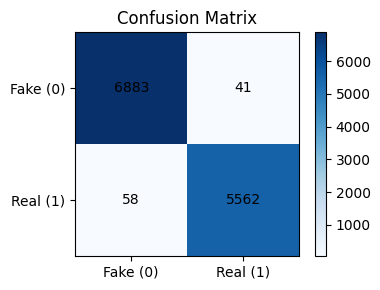

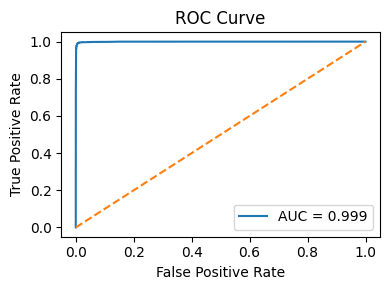


Saved final model + tokenizer to: /content/drive/MyDrive/Data-Single/model/


Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(



Sample Prediction:
Label: Real (1) | Confidence: 1.000


In [4]:
import os, sys, math, random, gc, time
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# =========================
# 1) Config (EDIT THESE if needed)
# =========================
TRAIN_CSV = "/content/drive/MyDrive/Data-Single/train_balanced.csv"  # change if your path differs
TEST_CSV  = "/content/drive/MyDrive/Data-Single/test.csv"            # change if your path differs

MODEL_NAME = "bert-base-uncased"
OUTPUT_DIR = "/content/drive/MyDrive/Data-Single/results/"             # trainer outputs/checkpoints
SAVE_DIR   = "/content/drive/MyDrive/Data-Single/model/"                 # final model+tokenizer dir

MAX_LENGTH = 256   # 128/256/384 (256 is a good speed/accuracy tradeoff)
BATCH_SIZE = 16    # 8/16 depending on GPU memory
EPOCHS     = 5     # 3-5 usually enough
LR         = 2e-5
SEED       = 42

# Mixed precision if CUDA available
USE_FP16 = torch.cuda.is_available()

# =========================
# 2) Reproducibility + Device
# =========================
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# 3) Load data
# =========================
def load_clean_csv(path):
    df = pd.read_csv(path)
    # Expect columns: text, label (0 = Fake, 1 = Real)
    # Basic safety checks
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError(f"{path} must have columns ['text','label']")

    # Drop NA and enforce string type
    before = len(df)
    df = df.dropna(subset=["text", "label"])
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(int)
    after = len(df)
    print(f"{os.path.basename(path)}: {before}->{after} rows after NA drop")
    return df

train_df = load_clean_csv(TRAIN_CSV)
test_df  = load_clean_csv(TEST_CSV)

print(train_df["label"].value_counts().rename({0:"Fake",1:"Real"}))
print(test_df["label"].value_counts().rename({0:"Fake",1:"Real"}))

# wrap as HF datasets
ds_train = Dataset.from_pandas(train_df, preserve_index=False)
ds_test  = Dataset.from_pandas(test_df,  preserve_index=False)
datasets = DatasetDict({"train": ds_train, "test": ds_test})

# =========================
# 4) Tokenizer + Tokenization
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,          # let DataCollator handle dynamic padding
        max_length=MAX_LENGTH,
    )

tokenized = datasets.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(type="torch")

# =========================
# 5) Data collator (dynamic padding)
# =========================
collator = DataCollatorWithPadding(tokenizer=tokenizer)

# =========================
# 6) Model
# =========================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

# =========================
# 7) Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    # binary (labels 0/1) metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }

# =========================
# 8) TrainingArguments + Trainer
# =========================
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_dir=os.path.join(OUTPUT_DIR, "logs"),
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=USE_FP16,
    report_to="none",  # set to "wandb" or "tensorboard" if you use them
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# =========================
# 9) Train
# =========================
train_result = trainer.train()
print("Best checkpoint:", trainer.state.best_model_checkpoint)

# =========================
# 10) Evaluate (Trainer metrics + detailed report)
# =========================
eval_metrics = trainer.evaluate()
print("\n== Trainer.evaluate() ==")
for k, v in eval_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(k, v)

# Detailed metrics: classification report, confusion matrix, ROC
pred = trainer.predict(tokenized["test"])
logits = pred.predictions
y_true = pred.label_ids
y_pred = np.argmax(logits, axis=1)

print("\n== Classification Report ==")
print(classification_report(y_true, y_pred, target_names=["Fake (0)", "Real (1)"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0,1], ["Fake (0)", "Real (1)"])
plt.yticks([0,1], ["Fake (0)", "Real (1)"])
for (i,j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

# ROC (need probabilities; for BERT, use softmax on logits)
from scipy.special import softmax
probs = softmax(logits, axis=1)[:, 1]
fpr, tpr, _ = roc_curve(y_true, probs)
auc = roc_auc_score(y_true, probs)
plt.figure(figsize=(4,3))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11) Save final model/tokenizer
# =========================
os.makedirs(SAVE_DIR, exist_ok=True)
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nSaved final model + tokenizer to: {SAVE_DIR}")

# =========================
# 12) Inference helper
# =========================
from transformers import TextClassificationPipeline

inference_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
inference_tok = AutoTokenizer.from_pretrained(SAVE_DIR)
pipe = TextClassificationPipeline(
    model=inference_model, tokenizer=inference_tok, device=0 if device=="cuda" else -1, return_all_scores=True
)

def predict_with_confidence(text):
    out = pipe(text, truncation=True, max_length=MAX_LENGTH)[0]
    # out = [{'label': 'LABEL_0', 'score': ...}, {'label': 'LABEL_1', 'score': ...}]
    scores = {d["label"]: d["score"] for d in out}
    # Map LABEL_0 -> Fake, LABEL_1 -> Real
    label_id = int(np.argmax([scores["LABEL_0"], scores["LABEL_1"]]))
    label_name = "Fake (0)" if label_id == 0 else "Real (1)"
    confidence = max(scores["LABEL_0"], scores["LABEL_1"])
    return label_name, confidence

# quick test
sample_text = "Breaking: Scientists announce a new method to detect fake news using AI."
label_name, conf = predict_with_confidence(sample_text)
print(f"\nSample Prediction:\nLabel: {label_name} | Confidence: {conf:.3f}")
